In [1]:
# Polymarket Test
from src.handlers.polymarket import PolymarketHandler
from src.utils.utils import *
from dotenv import load_dotenv
import copy
import requests
from datetime import datetime
from huggingface_hub import list_repo_files, hf_hub_download, login
import pprint
import time
import duckdb
import random
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

import os

# Load environment variables
load_dotenv()

# Make a PolymarketHandler instance
polymarketHandler = PolymarketHandler(
    polymarketAPIkey = os.getenv("polymarketAPI_key"),
    web3APIkey = os.getenv("alchemyAPI_key"),
    provider = "alchemy"
)

In [ ]:
lowestTimestamp = queryParquetFolder("./src/data/polymarket/trades", f"SELECT MIN(block_timestamp) AS largest_value FROM data").iloc[0,0]
print("The lowest timestamp that we have:", lowestTimestamp)

startTime_huggingFace = pd.DataFrame(queryParquetFile("src/data/polymarket/trades/polymarket_trades_pt_001.parquet", "SELECT MIN(block_timestamp) AS Starting_block FROM data")).iloc[0,0]
print("Starting block for higgingface acquired trades:", getBlockNumberFromTS(polymarketHandler.w3["polygon"], startTime_huggingFace))
print("Starting timestamp for higgingface acquired trades:", startTime_huggingFace)

add ending too
print("\n")

startBlock = pd.DataFrame(queryParquetFile("src/data/polymarket/trades/polymarket_trades_pt_018.parquet", "SELECT MIN(block_number) AS Starting_block FROM data")).iloc[0,0]
startTime = pd.DataFrame(queryParquetFile("src/data/polymarket/trades/polymarket_trades_pt_018.parquet", "SELECT MIN(block_timestamp) AS Starting_block FROM data")).iloc[0,0]
endBlock = queryParquetFolder("./src/data/polymarket/trades", f"SELECT MAX(block_number) AS largest_value FROM data").iloc[0,0]
endTime = queryParquetFolder("./src/data/polymarket/trades", f"SELECT MAX(block_timestamp) AS largest_value FROM data").iloc[0,0]
print("Starting block for rpc acquired trades:", startBlock)
print("Starting timestamp for rpc acquired trades:", startTime)
print("Ending block for rpc acquired trades:", endBlock)
print("Ending timestamp for rpc acquired trades:", endTime)
print("\n")


_max = pd.DataFrame(queryParquetFile("src/data/polymarket/trades/polymarket_trades_pt_018.parquet", "SELECT MAX(block_timestamp) AS largest_value FROM data")).iloc[0,0]
_min = pd.DataFrame(queryParquetFile("src/data/polymarket/trades/polymarket_trades_pt_019.parquet", "SELECT MIN(block_timestamp) AS largest_value FROM data")).iloc[0,0]
print("time difference with prev batch:", (_min-_max)/60/24, "days")

_max = pd.DataFrame(queryParquetFile("src/data/polymarket/trades/polymarket_trades_pt_018.parquet", "SELECT MAX(block_number) AS largest_value FROM data")).iloc[0,0]
_min = pd.DataFrame(queryParquetFile("src/data/polymarket/trades/polymarket_trades_pt_019.parquet", "SELECT MIN(block_number) AS largest_value FROM data")).iloc[0,0]
print("block difference with prev batch:", (_min-_max), "blocks")

_min = pd.DataFrame(queryParquetFile("src/data/polymarket/trades/polymarket_trades_pt_019.parquet", "SELECT MIN(block_timestamp) AS largest_value FROM data")).iloc[0,0]
_max = pd.DataFrame(queryParquetFile("src/data/polymarket/trades/polymarket_trades_pt_019.parquet", "SELECT MAX(block_timestamp) AS largest_value FROM data")).iloc[0,0]
print("time difference:", (_max-_min)/60/24, "days")

_min = pd.DataFrame(queryParquetFile("src/data/polymarket/trades/polymarket_trades_pt_019.parquet", "SELECT MIN(block_number) AS largest_value FROM data")).iloc[0,0]
_max = pd.DataFrame(queryParquetFile("src/data/polymarket/trades/polymarket_trades_pt_019.parquet", "SELECT MAX(block_number) AS largest_value FROM data")).iloc[0,0]
print("block difference:", (_max-_min), "blocks")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

The lowest timestamp that we have: 1669060209
Starting block for higgingface acquired trades: 35896869
Starting timestamp for higgingface acquired trades: 1669060209


Starting block for rpc acquired trades: 86126998
Starting timestamp for rpc acquired trades: 1777374040
Ending block for rpc acquired trades: 88253395
Ending timestamp for rpc acquired trades: 1781085078


time difference with prev batch: 0.001388888888888889 days
block difference with prev batch: 1 blocks
time difference: 17.77638888888889 days
block difference: 12799 blocks


In [3]:
allMarkets = pd.DataFrame(queryParquetFile("src/data/polymarket/historical_markets/polymarket_HistoricalMarkets.parquet", "SELECT * FROM data"))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [5]:
filteredmarkets = allMarkets[allMarkets.volumeNum > 1_000_000]

In [4]:
def plotOutcomes(dfs, dateRange, wonIndex: int, labels=None, title="Price Comparison",
                  figsize=(12, 6), fidelity=None, showLast = None):
    """
    Plots price data from an arbitrary number of dataframes on a single plot.

    Parameters:
        dfs : list of pd.DataFrame
            Each must have 'block_timestamp' and 'price' columns.
        dateRange : tuple/list of (start, end)
            Start and end datetimes (or timestamps) used to (a) anchor the
            start/finish points added to each series and (b) set the x-axis limits.
        wonIndex : int
            Index into dfs/labels of the winning outcome (its finishing price is set to 1;
            all others finish at 0).
        labels : list of str, optional
            Legend labels for each series. Defaults to "Series 1", "Series 2", ...
        title : str
            Plot title.
        figsize : tuple
            Figure size.
        fidelity : int, optional
            Resampling resolution in minutes, matching Polymarket's `fidelity` parameter
            (e.g. 1, 10, 60, 1440). If provided, each series is resampled/downsampled to
            this granularity (taking the last price in each bucket) before plotting.
        showLast : int
            Only show the last period in seconds
    """
    if labels is None:
        labels = [f"Series {i+1}" for i in range(len(dfs))]
    elif len(labels) != len(dfs):
        raise ValueError("Length of labels must match length of dfs")

    startDate = pd.to_datetime(dateRange[0], unit="s") if not isinstance(dateRange[0], pd.Timestamp) else dateRange[0]
    endDate = pd.to_datetime(dateRange[1], unit="s") if not isinstance(dateRange[1], pd.Timestamp) else dateRange[1]

    fig, ax = plt.subplots(figsize=figsize)

    for i, (df, label) in enumerate(zip(dfs, labels)):
        df = df.copy()
        df["block_timestamp"] = pd.to_datetime(df["block_timestamp"], unit="s")
        df = df.sort_values("block_timestamp")
        df = df[["block_timestamp", "price"]]

        # Apply Polymarket-style fidelity (resample to N-minute buckets)
        if fidelity is not None:
            df = (
                df.set_index("block_timestamp")
                  .resample(f"{fidelity}min")
                  .last()
                  .dropna()
                  .reset_index()
            )

        newRow = pd.DataFrame({'block_timestamp': [startDate], 'price': [1/len(dfs)]})
        df = pd.concat([newRow, df], ignore_index=True)

        # Add the finishing point (0 for losers and 1 for winner)
        finishPrice = 1 if i == wonIndex else 0
        newRow = pd.DataFrame({'block_timestamp': [endDate], 'price': [finishPrice]})
        df = pd.concat([df, newRow], ignore_index=True)

        ax.plot(df["block_timestamp"], df["price"], label=label, linewidth=1.5)

    ax.set_xlabel("Time")
    ax.set_ylabel("Price")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Set x-axis to the requested date range
    if showLast:
        ax.set_xlim(max(endDate - pd.Timedelta(seconds=showLast), startDate), endDate)
    else:
        ax.set_xlim(startDate, endDate)

    # Human-readable date formatting
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d, %Y"))
    fig.autofmt_xdate()
    
    plt.tight_layout()
    plt.show()
    return fig, ax

In [7]:
xxx = queryParquetFolder("./src/data/polymarket/trades", f"SELECT MIN(block_number) AS max_value FROM data WHERE block_number <> -1")

In [6]:
marketData = pd.DataFrame(queryParquetFile("src/data/polymarket/historical_markets/polymarket_HistoricalMarkets.parquet", f"SELECT * FROM data WHERE slug = 'us-x-cuba-diplomatic-meeting-by-may-31-265'"))
marketData.iloc[0].outcome_1_ID

'101881991046648004600006951072556195736778617904900045738563947935423969083026'

In [13]:
_trades = pd.DataFrame(queryParquetFolder("./src/data/polymarket/trades", f"SELECT * FROM data WHERE token_id = '101881991046648004600006951072556195736778617904900045738563947935423969083026'"))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [11]:
for file in sorted(os.listdir("./src/data/polymarket/trades"), key = lambda x: int(x.replace("polymarket_trades_pt_", "").replace(".parquet", ""))):
    if file.endswith(".parquet"):
        trades = pd.DataFrame(queryParquetFile(f"src/data/polymarket/trades/{file}", f"SELECT * FROM data WHERE tx_hash = '0x8020a592be86aa047f0dffcb01d8945ffea3cc376f883e06ae27cf8b41b8bf83'"))
        if trades.shape[0] != 0:
            print(f"Trades found in {file}: {trades.shape[0]} rows")

Trades found in polymarket_trades_pt_130.parquet: 2 rows


In [16]:
print("wrong trades:", _trades[_trades.price > 1].shape)
print(_trades[_trades.price > 1].iloc[0])
print( _trades[_trades.price > 1].iloc[0].tx_hash)

t1 = _trades[_trades.tx_hash == _trades[_trades.price > 1].iloc[0].tx_hash].iloc[0]
t2 = _trades[_trades.tx_hash == _trades[_trades.price > 1].iloc[0].tx_hash].iloc[1]
print("")
print(t2.price)
print(t2.extra_data)

wrong trades: (2041, 17)
block_number                                                 87302456
block_timestamp                                            1779519006
tx_hash             0x8020a592be86aa047f0dffcb01d8945ffea3cc376f88...
platform_name                                              polymarket
platform_version                                               ctf_v2
taker                      0xE111180000d2663C0091e4f400237545B87B996B
maker                      0x4BAba0910356Ce52384d6A0731C068A4EC10b271
token_id            1018819910466480046000069510725561957367786179...
slug                                                             None
condition_id                                                     None
price                                                        1.190476
taker_side                                                       SELL
amount                                                           20.0
amount_asset                                                     

In [7]:
# Plot a polymarket's market 

# Get the market's data - one token ID has to be given
_idx = random.randint(0, filteredmarkets.shape[0])
slug = filteredmarkets.iloc[_idx].slug
marketData = pd.DataFrame(queryParquetFile("src/data/polymarket/historical_markets/polymarket_HistoricalMarkets.parquet", f"SELECT * FROM data WHERE slug = '{slug}'"))

outcome_0_trades = queryParquetFolder("./src/data/polymarket/trades", f"SELECT * FROM data WHERE token_id = '{marketData.iloc[0].outcome_0_ID}'")
outcome_1_trades = queryParquetFolder("./src/data/polymarket/trades", f"SELECT * FROM data WHERE token_id = '{marketData.iloc[0].outcome_1_ID}'")

print(f"Index: {_idx}")
print(f"Slug: {marketData.iloc[0].slug}")
print(f"Market ID: {marketData.iloc[0].marketID}")
print(f"Outcome 0: {marketData.iloc[0].outcome_0} ({marketData.iloc[0].outcome_0_ID[0:10]}...{marketData.iloc[0].outcome_0_ID[-10:]})")
print(f"Outcome 1: {marketData.iloc[0].outcome_1} ({marketData.iloc[0].outcome_1_ID[0:10]}...{marketData.iloc[0].outcome_1_ID[-10:]})")
print(f"Total trades count: {outcome_0_trades.shape[0] + outcome_1_trades.shape[0]:,}")
print(f"Volum: {marketData.iloc[0].volumeNum}")
# print(f"Duration: {(allTrades.iloc[-1].block_timestamp - allTrades.iloc[0].block_timestamp)/60/24}")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Index: 3858
Slug: us-x-cuba-diplomatic-meeting-by-may-31-265
Market ID: 2325706
Outcome 0: Yes (2271309309...8784511003)
Outcome 1: No (1018819910...3969083026)
Total trades count: 11,545
Volum: 2303526.1878300034


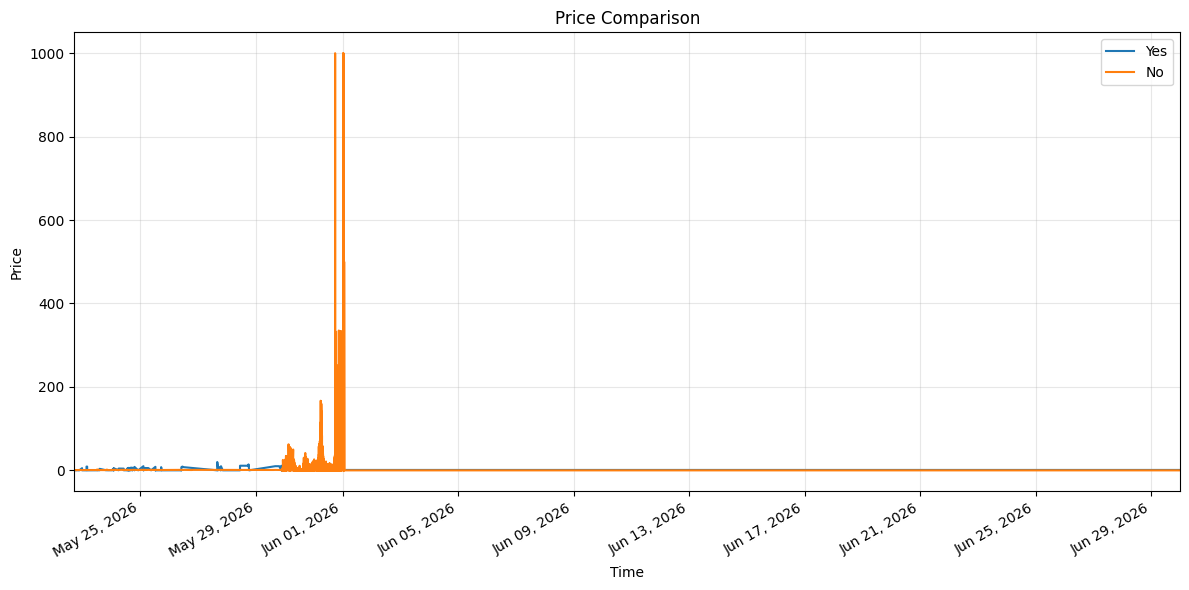

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Price Comparison'}, xlabel='Time', ylabel='Price'>)

In [8]:
dateRange = [
    int(min(datetime.fromisoformat(marketData.startDate.iloc[0]).timestamp(), outcome_0_trades.block_timestamp.min(), outcome_1_trades.block_timestamp.min())),
    int(max(datetime.fromisoformat(marketData.endDate.iloc[0]).timestamp(), outcome_0_trades.block_timestamp.max(), outcome_1_trades.block_timestamp.max()))
]

wonIndex = 0 if marketData.outcome_0_price.iloc[0] == 1.0 else 1

plotOutcomes(
    dfs = [outcome_0_trades, outcome_1_trades],
    labels = [marketData.iloc[0].outcome_0, marketData.iloc[0].outcome_1],
    dateRange = dateRange,
    wonIndex = wonIndex,
    # showLast = 4 * 60 * 60
    # fidelity = 5
)

In [12]:
outcome_0_trades[outcome_0_trades.price>.6]

,block_number,block_timestamp,tx_hash,platform_name,platform_version,taker,maker,token_id,slug,condition_id,price,taker_side,amount,amount_asset,fee,fee_asset,extra_data
242,-1,1720136888,None,None,None,0xB33B378b46A16718FD09Ce6a586380268489092f,0xc903739e6536DD9a01Cc9b94219Ea687D286765a,4030686189377282389561627512436277034329184154...,None,0x74f97b1c6caf682f5ef9ccd325b3344959bf8fd38fe5...,0.652,BUY,3.260000,None,0.0,None,None
243,-1,1720136888,None,None,None,0xB33B378b46A16718FD09Ce6a586380268489092f,0x7ED2453eAE806B41B05c2D6CDA62e72b51c8b32C,4030686189377282389561627512436277034329184154...,None,0x74f97b1c6caf682f5ef9ccd325b3344959bf8fd38fe5...,0.659,BUY,152.609799,None,0.0,None,None
3730,-1,1721846657,None,None,None,0x715e4430442e3c7bf152041ac5A1A9D9B234E9df,0xF5b199eb2870f3A338b02Ea01D0B6902Ab43A12E,4030686189377282389561627512436277034329184154...,None,0x74f97b1c6caf682f5ef9ccd325b3344959bf8fd38fe5...,0.650,BUY,45.500000,None,0.0,None,None
3731,-1,1721846657,None,None,None,0x715e4430442e3c7bf152041ac5A1A9D9B234E9df,0xf3AF4E96D0e44C9c18204Ac431dD41e440459fe8,4030686189377282389561627512436277034329184154...,None,0x74f97b1c6caf682f5ef9ccd325b3344959bf8fd38fe5...,0.650,BUY,81.250000,None,0.0,None,None
3732,-1,1721846657,None,None,None,0x715e4430442e3c7bf152041ac5A1A9D9B234E9df,0x55Db7Fc264f1c1E863ec1D29777cb20892947cE1,4030686189377282389561627512436277034329184154...,None,0x74f97b1c6caf682f5ef9ccd325b3344959bf8fd38fe5...,0.680,BUY,680.000000,None,0.0,None,None
3733,-1,1721846657,None,None,None,0x715e4430442e3c7bf152041ac5A1A9D9B234E9df,0x287e874e8bcD59DD3ce307E1881574742a3072cc,4030686189377282389561627512436277034329184154...,None,0x74f97b1c6caf682f5ef9ccd325b3344959bf8fd38fe5...,0.900,BUY,30973.755858,None,0.0,None,None
3734,-1,1721846689,None,None,None,0x715e4430442e3c7bf152041ac5A1A9D9B234E9df,0x287e874e8bcD59DD3ce307E1881574742a3072cc,4030686189377282389561627512436277034329184154...,None,0x74f97b1c6caf682f5ef9ccd325b3344959bf8fd38fe5...,0.900,BUY,64432.467000,None,0.0,None,None
3735,-1,1721846689,None,None,None,0x715e4430442e3c7bf152041ac5A1A9D9B234E9df,0xc903739e6536DD9a01Cc9b94219Ea687D286765a,4030686189377282389561627512436277034329184154...,None,0x74f97b1c6caf682f5ef9ccd325b3344959bf8fd38fe5...,0.900,BUY,195.552000,None,0.0,None,None
3736,-1,1721846689,None,None,None,0x715e4430442e3c7bf152041ac5A1A9D9B234E9df,0xfFa10CA842A2f01435aFe845A0A8181d3c27CD34,4030686189377282389561627512436277034329184154...,None,0x74f97b1c6caf682f5ef9ccd325b3344959bf8fd38fe5...,0.980,BUY,49.000000,None,0.0,None,None
3737,-1,1721846689,None,None,None,0x715e4430442e3c7bf152041ac5A1A9D9B234E9df,0x1cD9421f37bc75737ac55c1095bdA0442f950c0E,4030686189377282389561627512436277034329184154...,None,0x74f97b1c6caf682f5ef9ccd325b3344959bf8fd38fe5...,0.990,BUY,777.852900,None,0.0,None,None
